In [1]:
import pandas as pd

In [3]:
# Load datasets
customers = pd.read_csv("customers.csv", parse_dates=["Join_date"])
transactions = pd.read_csv("transactions.csv", parse_dates=["Order_date"])

In [4]:
# Merge datasets on Customer_id
data = transactions.merge(customers, on="Customer_id", how="left")

In [5]:
# Drop duplicates
data = data.drop_duplicates()

In [6]:
print("Missing values per column:\n", data.isnull().sum())

Missing values per column:
 Customer_id     0
Order_id        0
Order_date      0
Order_amount    0
Join_date       0
Gender          0
Age             0
dtype: int64


In [7]:
print("\nMerged data sample:\n", data.head())


Merged data sample:
   Customer_id     Order_id Order_date  Order_amount  Join_date Gender  Age
0   CUST00001  ORDF60D29D8 2023-05-17        383.31 2023-06-02  Other   59
1   CUST00001  ORD18AFDB98 2023-10-22        343.37 2023-06-02  Other   59
2   CUST00001  ORD5D9E695B 2024-08-13        301.95 2023-06-02  Other   59
3   CUST00001  ORD04746CE6 2024-02-23        395.81 2023-06-02  Other   59
4   CUST00001  ORDA9276CFE 2025-01-29        267.50 2023-06-02  Other   59


In [8]:
# Set reference date = 1 day after the most recent order date
reference_date = data["Order_date"].max() + pd.Timedelta(days=1)

In [9]:
features = data.groupby("Customer_id").agg(
    Frequency=("Order_id", "count"),
    Monetary=("Order_amount", "sum"),
    Last_Order_Date=("Order_date", "max"),
    First_Order_Date=("Order_date", "min")
).reset_index()


In [10]:
features["Recency"] = (reference_date - features["Last_Order_Date"]).dt.days
features["Tenure"] = (features["Last_Order_Date"] - features["First_Order_Date"]).dt.days
features["AOV"] = features["Monetary"] / features["Frequency"]

In [11]:
print("Feature set sample:")
print(features.head())

Feature set sample:
  Customer_id  Frequency  Monetary Last_Order_Date First_Order_Date  Recency  \
0   CUST00001          7   2148.01      2025-02-21       2023-05-17       68   
1   CUST00002         19   4929.51      2025-04-14       2024-02-20       16   
2   CUST00003         10   2864.61      2025-04-22       2024-04-21        8   
3   CUST00004          3    885.19      2025-02-27       2024-06-15       62   
4   CUST00005          6   2300.40      2025-03-07       2024-07-05       54   

   Tenure         AOV  
0     646  306.858571  
1     419  259.447895  
2     366  286.461000  
3     257  295.063333  
4     245  383.400000  


In [13]:
features["LTV"] = features["Monetary"]


In [15]:
features = features.drop(columns=["Monetary"])  #to prevent data leakage during training

In [16]:
features = features[["Customer_id", "Frequency", "Recency", "Tenure", "AOV", "LTV"]]

In [17]:
print("Final dataset sample:")
print(features.head())

Final dataset sample:
  Customer_id  Frequency  Recency  Tenure         AOV      LTV
0   CUST00001          7       68     646  306.858571  2148.01
1   CUST00002         19       16     419  259.447895  4929.51
2   CUST00003         10        8     366  286.461000  2864.61
3   CUST00004          3       62     257  295.063333   885.19
4   CUST00005          6       54     245  383.400000  2300.40


In [18]:
#Train/Test Split and Scaling.



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
# Drop Customer_id for modeling
X = features.drop(columns=["Customer_id", "LTV"])
y = features["LTV"]


In [21]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Feature scaling (optional but recommended for linear models)


In [23]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1200, 4)
Test set shape: (300, 4)


In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [25]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train) # train model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
y_pred = model.predict(X_test_scaled)   #Prediction

In [27]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


In [28]:
print("Model Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Performance:
MAE:  28.27
RMSE: 39.78


In [29]:
from sklearn.model_selection import RandomizedSearchCV


In [30]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
rs = RandomizedSearchCV(xgb, params, n_iter=25, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_

In [33]:
import shap

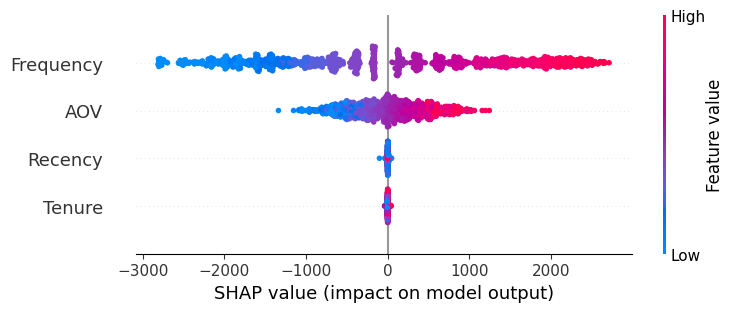

In [34]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values)

In [38]:
df_customers = pd.read_csv("customers.csv")  # adjust path

In [41]:
df_txns = pd.read_csv("transactions.csv")

In [43]:
print(df_txns.columns)


Index(['Customer_id', 'Order_id', 'Order_date', 'Order_amount'], dtype='object')


In [45]:
# Convert Order_date to datetime
df_txns['Order_date'] = pd.to_datetime(df_txns['Order_date'])

# Use the latest order date as reference
reference_date = df_txns['Order_date'].max()

# Feature engineering
agg = df_txns.groupby('Customer_id').agg(
    Frequency=('Order_id', 'count'),
    Recency=('Order_date', lambda x: (reference_date - x.max()).days),
    Tenure=('Order_date', lambda x: (reference_date - x.min()).days),
    AOV=('Order_amount', 'mean')
).reset_index()

# Load customer file if not already done
df_customers = pd.read_csv("customers.csv")

# Merge engineered features with customers
X_all_customers = df_customers.merge(agg, on='Customer_id', how='left')

# Keep only model input features
X_features = X_all_customers[['Frequency', 'Recency', 'Tenure', 'AOV']]


In [46]:
# Predict LTV
preds = best_model.predict(X_features)
df_customers['predicted_LTV'] = preds

# Export
df_customers.to_csv('customer_LTV_predictions.csv', index=False)


In [47]:
# Fill NaNs and Predict

In [48]:
X_features_filled = X_features.fillna(0)


In [49]:
preds = best_model.predict(X_features_filled)
df_customers['predicted_LTV'] = preds

In [50]:
df_customers['no_history'] = X_features.isna().any(axis=1).astype(int)

In [51]:
df_customers.to_csv('customer_LTV_predictions.csv', index=False)

In [52]:
#LTV Distribution Plot

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

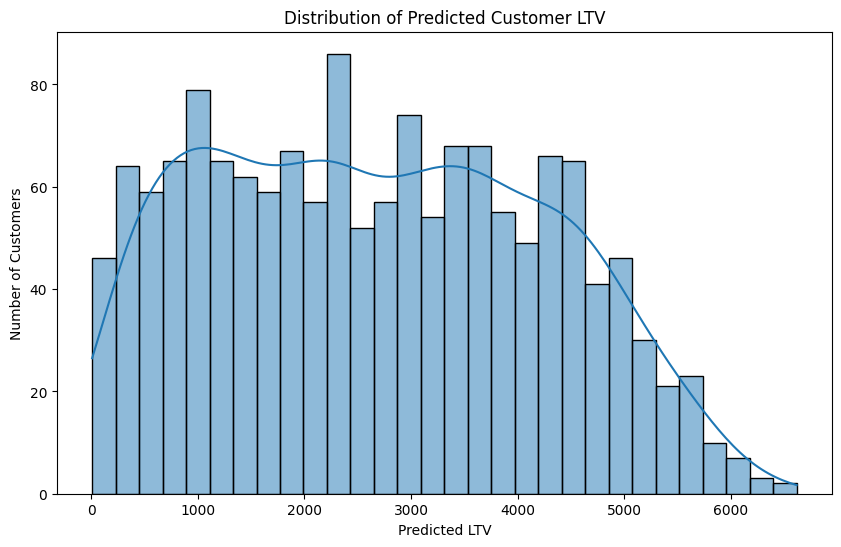

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(df_customers['predicted_LTV'], bins=30, kde=True)
plt.title('Distribution of Predicted Customer LTV')
plt.xlabel('Predicted LTV')
plt.ylabel('Number of Customers')
plt.show()

In [55]:
# Custom Buckets (based on business rules)

In [56]:
df_customers['LTV_segment'] = pd.cut(
    df_customers['predicted_LTV'],
    bins=[-float('inf'), 500, 1000, 2000, float('inf')],
    labels=['Low', 'Mid', 'High', 'Top']
)

In [57]:
segment_summary = df_customers.groupby('LTV_segment')['predicted_LTV'].agg(['count', 'mean', 'min', 'max'])
print(segment_summary)


             count         mean          min          max
LTV_segment                                              
Low            130   305.354492    10.220800   499.315826
Mid            141   781.088928   509.328033   999.580627
High           296  1482.896484  1000.326660  1994.005127
Top            933  3671.733154  2013.520142  6616.727539


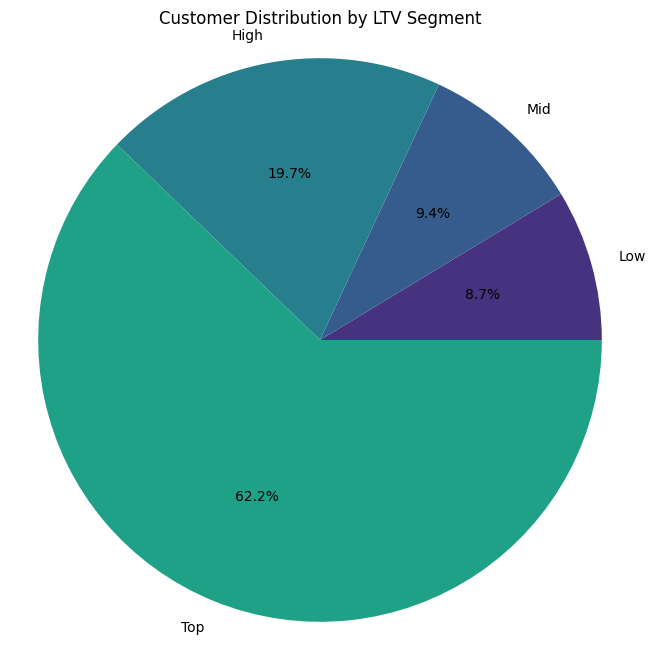

In [59]:
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Customer Distribution by LTV Segment')
plt.axis('equal')
plt.show()


In [60]:
df_customers.to_csv('customer_LTV_segmented.csv', index=False)


In [61]:
#Model Evaluation

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np



In [63]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 32.49, RMSE: 49.66


In [65]:
#Improve High-Error Predictions

In [66]:
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

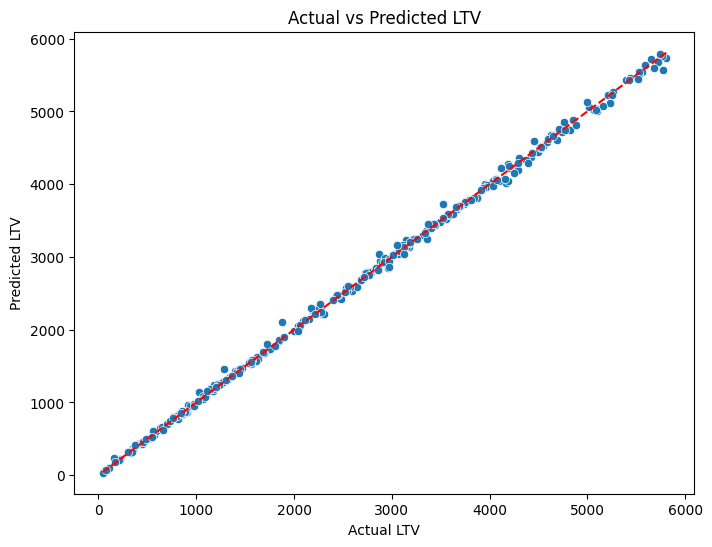

In [69]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")
plt.show()